In [1]:
import os
import json
from pathlib import Path

In [2]:
def process_timit_dataset(dataset_path="./Dataset"):
    """
    处理TIMIT数据集，创建trainset.json和testset.json
    
    Args:
        dataset_path: 数据集根目录路径
    """
    # 定义结果存储
    train_data = []
    test_data = []
    
    # 处理TRAIN和TEST目录
    for split in ["TRAIN", "TEST"]:
        split_path = os.path.join(dataset_path, split)
        
        # 遍历每个方言区域文件夹 (DR1-DR8)
        for dr_folder in sorted([f for f in os.listdir(split_path) if f.startswith("DR")]):
            dr_path = os.path.join(split_path, dr_folder)
            
            # 遍历每个说话人文件夹
            for speaker_folder in os.listdir(dr_path):
                speaker_path = os.path.join(dr_path, speaker_folder)
                
                # 解析说话人信息
                gender = "F" if speaker_folder.startswith("F") else "M"
                speaker_id = speaker_folder[1:]  # 移除首字母F或M
                
                # 遍历每个音频文件
                for audio_file in os.listdir(speaker_path):
                    # 跳过合并结果文件
                    if audio_file == "merge_result.wav":
                        continue
                    
                    # 只处理wav文件
                    if audio_file.endswith(".wav"):
                        # 构建相对路径
                        audio_filepath = os.path.join(".", "Dataset", split, dr_folder, 
                                                      speaker_folder, audio_file)
                        
                        # 规范化路径分隔符为正斜杠
                        audio_filepath = audio_filepath.replace(os.sep, "/")
                        
                        # 创建条目
                        entry = {
                            "audio_filepath": audio_filepath,
                            "dialect_region": dr_folder,
                            "gender": gender,
                            "speaker_id": speaker_id
                        }
                        
                        # 添加到对应的数据集
                        if split == "TRAIN":
                            train_data.append(entry)
                        else:
                            test_data.append(entry)
    
    # 保存结果到JSON文件
    with open("./trainset.json", "w", encoding="utf-8") as f:
        json.dump(train_data, f, indent=2, ensure_ascii=False)
    
    with open("./testset.json", "w", encoding="utf-8") as f:
        json.dump(test_data, f, indent=2, ensure_ascii=False)
    
    print(f"处理完成，共生成训练集样本 {len(train_data)} 个，测试集样本 {len(test_data)} 个")


In [3]:
process_timit_dataset()

处理完成，共生成训练集样本 2772 个，测试集样本 924 个


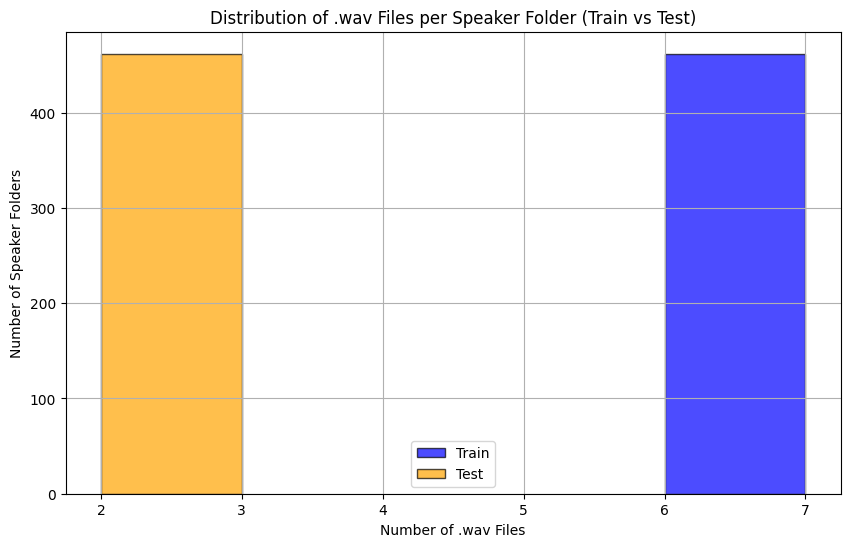

In [4]:
import os
import matplotlib.pyplot as plt

def plot_wav_file_distribution(dataset_path="./Dataset"):
    """
    统计TIMIT数据集中每个说话人文件夹中.wav文件的数量，并绘制分布图。
    
    Args:
        dataset_path: 数据集根目录路径
    """
    # 用于存储TRAIN和TEST每个说话人文件夹的.wav文件数量
    train_wav_counts = []
    test_wav_counts = []
    
    # 处理TRAIN和TEST目录
    for split in ["TRAIN", "TEST"]:
        split_path = os.path.join(dataset_path, split)
        
        # 遍历每个方言区域文件夹 (DR1-DR8)
        for dr_folder in sorted([f for f in os.listdir(split_path) if f.startswith("DR")]):
            dr_path = os.path.join(split_path, dr_folder)
            
            # 遍历每个说话人文件夹
            for speaker_folder in os.listdir(dr_path):
                speaker_path = os.path.join(dr_path, speaker_folder)
                
                # 统计.wav文件数量
                wav_count = 0
                # 遍历每个音频文件
                for audio_file in os.listdir(speaker_path):
                    if audio_file.endswith(".wav") and audio_file != "merge_result.wav":
                        wav_count += 1
                
                # 将说话人文件夹中的.wav文件数量添加到统计列表中
                if split == "TRAIN":
                    train_wav_counts.append(wav_count)
                else:
                    test_wav_counts.append(wav_count)
    
    # 绘制分布图
    plt.figure(figsize=(10, 6))
    
    # 绘制TRAIN数据集的分布
    plt.hist(train_wav_counts, bins=range(min(train_wav_counts), max(train_wav_counts) + 2), 
             edgecolor='black', alpha=0.7, label='Train', color='blue')
    
    # 绘制TEST数据集的分布
    plt.hist(test_wav_counts, bins=range(min(test_wav_counts), max(test_wav_counts) + 2), 
             edgecolor='black', alpha=0.7, label='Test', color='orange')
    
    plt.title("Distribution of .wav Files per Speaker Folder (Train vs Test)")
    plt.xlabel("Number of .wav Files")
    plt.ylabel("Number of Speaker Folders")
    plt.legend()
    plt.grid(True)
    plt.show()

# 调用函数绘制分布图
plot_wav_file_distribution()
